# PNAS interpretable splicing model on opensplice exons

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import sys

pd.set_option("display.max_columns", None)

BASE = Path("/scratch/abr10036/projects/2026-exon-structure/2026-07-opensplice")
DATA    = BASE / "data"
OUTPUTS = BASE / "outputs"
FIGURES = BASE / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

ROOT = Path("/scratch/abr10036/projects/2026-exon-structure")
REPO = ROOT / "interpretable-splicing-model-torch"
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(ROOT / ".pylibs"))


def despine(ax):
    """Drop the top/right spines; used on every panel below."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    return ax

# Publication-style settings
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


---
## 1. Build the sequence definitions

`opensplice_dataset.tsv` stores each library member as a single `nt_seq`. The exon and its
two flanking contexts are fixed offsets into that sequence:

* `exon` — the exon body, `nt_seq[68:-23]`
* `exon_with_splice_site` — `nt_seq[63:-18]`, i.e. `pnas_exon` plus 10 nt of real genomic
  context on each side

For every exon long enough to survive the trim, `len(exon_with_splice_site) ==
len(pnas_exon) + 20`, so the two definitions give the model inputs of *identical length*
and their MFEs are directly comparable. The exception is very short exons, where
`exon[5:-5]` clamps to an empty or truncated string and the relation breaks.

In [ ]:
df = pd.read_csv(DATA / "Supplementary_Table4.tsv", sep="\t")

# Not accounting for deletions (since we will subset later).
df["exon"]         = df["nt_seq"].apply(lambda x: x[70:-25])

# Flanking with 'true' flanks, not PNAS flanks
df["flanked_exon"] = df["nt_seq"].apply(lambda x: x[63:-18])

print(f"{len(df):,} library members")

882,382 library members
offset == 20 for 99.701% of rows (2,639 short-exon exceptions)


### WT exons and exonic variants

We gather just the wildtype exons by selecting those that have variant ID ending in 'wt' There are a lot of duplicate entries with identical WT PSI values, as well as a handful (7) with no WT PSI, so these are dropped.

In [ ]:
wt_exons = (
    df[df["variant_id"].str.endswith("wt")]
    .dropna(subset=["psi"])
    .drop_duplicates(subset=["exon_id"])
)
wt_exons["length"] = wt_exons["nt_seq"].str.len()

,CHROM,POS,REF,ALT,exon_id,ensembl_exon_id,variant_id,nt_seq,lib_id,start,end,length,wt,mut,mut_type,region,region_start,region_end,exon_length,psi_r1,psi_r2,psi_r3,wt_psi,psi,delta_psi,se_psi,logit_psi_wt,logit_psi,delta_logit,padj,significant,delta_bin,clinvar_mut,mc,mc_simple,clnsig_simple,status_simple,exon,pnas_exon,flanked_exon
39062,NaN,NaN,NaN,NaN,FOXP1_e13,NaN,FOXP1_e13_wt,AACCCCGTCTCCTTTTGTTGCCACTCCATCTCCTTTGCTGCTGCTC...,P3,1,1,0,A,A,wt,Intron up,Intron up,Intron up,155.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,AACCTCTCACTGCATAAGTGCTTTATCAGAGTAGAGGATGAGTTTG...,CTCTCACTGCATAAGTGCTTTATCAGAGTAGAGGATGAGTTTGGGT...,TCGCACCAACCTCTCACTGCATAAGTGCTTTATCAGAGTAGAGGAT...
50451,NaN,NaN,NaN,NaN,PKM_e9,NaN,PKM_e9_wt,AAGCTCTGACAAAGCTCTGTCCCCCTCTCGTCCCTCTGGACGGATG...,P3,1,1,0,A,A,wt,Intron up,Intron up,Intron up,155.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,GCAGAGGCTGCCATCTACCACTTGCAATTATTTGAGGAACTCCGCC...,GAGGCTGCCATCTACCACTTGCAATTATTTGAGGAACTCCGCCGCC...,CCGTGAGGCAGAGGCTGCCATCTACCACTTGCAATTATTTGAGGAA...
211825,NaN,NaN,NaN,NaN,KIF12_e6,NaN,KIF12_e6_wt,ATCATACATGCGCTACAGAGGGTAGTTATTACTGTGGAGATGACGA...,MUT6,1,1,0,A,A,wt,Intron up,Intron up,Intron up,135.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,GGGGAGGGGGTGCCTGTACCCCCCAGCCTGGCTGGCATCATGCAGA...,GAGGGGGTGCCTGTACCCCCCAGCCTGGCTGGCATCATGCAGAGGA...,CCCCTAGGGGGAGGGGGTGCCTGTACCCCCCAGCCTGGCTGGCATC...
369952,NaN,NaN,NaN,NaN,PKM_e10,NaN,PKM_e10_wt,CTCGTTTTTTTCCTCCTCCTTCCCTCTTCCTTGCCCCCTCTTCCCC...,P3,1,1,0,C,C,wt,Intron up,Intron up,Intron up,155.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,GCTGAGGCAGCCATGTTCCACCGCAAGCTGTTTGAAGAACTTGTGC...,GAGGCAGCCATGTTCCACCGCAAGCTGTTTGAAGAACTTGTGCGAG...,TCGTGAGGCTGAGGCAGCCATGTTCCACCGCAAGCTGTTTGAAGAA...
511431,NaN,NaN,NaN,NaN,SMNDC1_e3,NaN,SMNDC1_e3_wt,GGCAGGGGTCAAGTCACTTGTCTCATATATTACAGTGGCTCTCTGC...,P3,1,1,0,G,G,wt,Intron up,Intron up,Intron up,155.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,AAGCAGAGTGCTTGAGTGCACCCCATTTGACCTGCTGATATGTAGA...,CAGAGTGCTTGAGTGCACCCCATTTGACCTGCTGATATGTAGATCA...,CTTCAGTAAGCAGAGTGCTTGAGTGCACCCCATTTGACCTGCTGAT...
575573,NaN,NaN,NaN,NaN,PKLR_e4,NaN,PKLR_e4_wt,GTGGGGCAGGAGGATGCCTCGAGGTCCTGGCCACCTTCCCCTGAAA...,MUT6,1,1,0,G,G,wt,Intron up,Intron up,Intron up,132.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,TACCATGCTGAGTCCATCGCCAACGTCCGGGAGGCGGTGGAGAGCT...,CATGCTGAGTCCATCGCCAACGTCCGGGAGGCGGTGGAGAGCTTTG...,CCCCCAGTACCATGCTGAGTCCATCGCCAACGTCCGGGAGGCGGTG...
765316,NaN,NaN,NaN,NaN,POLE_e21,NaN,POLE_e21_wt,TGGGCTATTGACTTTGTAGAATGTGAAATGGAAGAATCTGTGAGGT...,MUT6,1,1,0,U,U,wt,Intron up,Intron up,Intron up,149.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,mid,NaN,NaN,NaN,NaN,NaN,GTGTGGAAAAAGAAGCTCTCGGCGGCCGTGGAGGTGGGCGACGCGG...,TGGAAAAAGAAGCTCTCGGCGGCCGTGGAGGTGGGCGACGCGGCTG...,TTCTCAGGTGTGGAAAAAGAAGCTCTCGGCGGCCGTGGAGGTGGGC...


In [ ]:
# Merge the wild-type sequences into the main dataframe to calculate the wild-type exon lengths
df = df.merge(
    wt_exons[["exon_id", "nt_seq", "length"]].rename(columns={"nt_seq": "wt_seq", "length": "wt_length"}), on="exon_id"
)

# Define the wild-type exon length as the length of the wild-type sequence minus the flanking regions (70 + 25)
df['wt_exon_length'] = df['wt_length'] - (70 + 25)

# OpenSplice exon structure (not accounting for deletions): [68 upstream nt][AG][exon body][GT][23 downstream nt]

# One WT row per exon (dropping exons with no measured PSI), and a variant is called exonic
# when it falls strictly inside the exon body: (start >= 71 & end < (71 + wt_exon_length))
# Note that start is 1-indexed
df["exonic_variant"] = (
    (~df["ALT"].isna()) &                               # is a variant
    (df['mut_type'] == 'sub') &                         # is a single-nucleotide substitution
    (df["start"] >= 71) &                               # occurs after 'AG' dinucleotide
    (df['start'] < (71 + df['wt_exon_length']))         # occurs before 'GT' dinucleotide
)

exonic_variants = df[df["exonic_variant"]].drop_duplicates(subset="variant_id")
print(f"{len(wt_exons):,} WT exons | {len(exonic_variants):,} exonic variants")

601 WT exons | 160,608 exonic variants


In [ ]:
exonic_variants.sort_values(by='wt_exon_length', ascending=False)

,CHROM,POS,REF,ALT,exon_id,ensembl_exon_id,variant_id,nt_seq,lib_id,start,end,length,wt,mut,mut_type,region,region_start,region_end,exon_length,psi_r1,psi_r2,psi_r3,wt_psi,psi,delta_psi,se_psi,logit_psi_wt,logit_psi,delta_logit,padj,significant,delta_bin,clinvar_mut,mc,mc_simple,clnsig_simple,status_simple,exon,pnas_exon,flanked_exon,wt_seq,wt_length,wt_exon_length,exonic_variant
281036,chr2,140813757,C,T,LRP1B_e32,ENSE00001153769,LRP1B_e32_G120A,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,MUT6,120,120,1,G,A,sub,Exon,Exon,Exon,150.0,11.111111,50.000000,60.000000,51.977136,58.006820,6.029684,11.812976,0.079127,0.323053,0.243927,8.040405e-01,no,mid,chr2:140813757C>T,NaN,NaN,NaN,NaN,GTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTC...,TATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTCAGG...,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,245,150,True
281045,chr2,140813757,C,G,LRP1B_e32,ENSE00001153769,LRP1B_e32_G120C,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,MUT6,120,120,1,G,C,sub,Exon,Exon,Exon,150.0,18.320611,46.666667,32.653061,51.977136,57.775918,5.798783,4.531506,0.079127,0.313581,0.234455,4.235469e-01,no,mid,chr2:140813757C>G,NaN,NaN,NaN,NaN,GTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTC...,TATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTCAGG...,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,245,150,True
281047,chr2,140813754,A,T,LRP1B_e32,ENSE00001153769,LRP1B_e32_T123A,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,MUT6,123,123,1,U,A,sub,Exon,Exon,Exon,150.0,13.793103,30.000000,47.368421,51.977136,50.219079,-1.758056,5.491761,0.079127,0.008763,-0.070363,8.902817e-01,no,mid,chr2:140813754A>T,NaN,NaN,NaN,NaN,GTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTC...,TATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTCAGG...,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,245,150,True
281052,chr2,140813754,A,G,LRP1B_e32,ENSE00001153769,LRP1B_e32_T123C,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,MUT6,123,123,1,U,C,sub,Exon,Exon,Exon,150.0,20.338983,50.000000,45.000000,51.977136,60.301511,8.324375,6.332920,0.079127,0.418044,0.338917,4.122083e-01,no,mid,chr2:140813754A>G,NaN,NaN,NaN,NaN,GTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTC...,TATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTCAGG...,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,245,150,True
281099,chr2,140813738,A,G,LRP1B_e32,ENSE00001153769,LRP1B_e32_T139C,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,MUT6,139,139,1,U,C,sub,Exon,Exon,Exon,150.0,18.260870,13.513514,44.680851,51.977136,53.391497,1.414361,3.605784,0.079127,0.135869,0.056742,8.597236e-01,no,mid,chr2:140813738A>G,NaN,NaN,NaN,NaN,GTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTC...,TATCGATAGACTATGTGGAAAACAAGCTTTATTGGATCAGTTCAGG...,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...,CAGTGGTGCTAGGTGGATATTACAATTTAAGTGGCTATCATTATGT...,245,150,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701341,chr11,47343260,T,C,MYBPC3_e14,ENSE00001799700,MYBPC3_e14_A73G,TCTCTCTCCTTTTGTCTCGGGCTCACTTCCTCCCGTCGGGAACACT...,MUT1,73,73,1,A,G,sub,5'SS,Exon,Exon,3.0,74.389771,60.647280,60.674157,69.691498,74.256568,4.565070,0.545323,0.832650,1.059347,0.226697,2.672095e-15,yes,pos1,chr11:47343260T>C,NaN,NaN,NaN,NaN,CAG,,TCTACAGCAGGTAAGTT,TCTCTCTCCTTTTGTCTCGGGCTCACTTCCTCCCGTCGGGAACACT...,98,3,True
701351,chr11,47343261,T,A,MYBPC3_e14,ENSE00001799700,MYBPC3_e14_A72T,TCTCTCTCCTTTTGTCTCGGGCTCACTTCCTCCCGTCGGGAACACT...,MUT1,72,72,1,A,U,sub,5'SS,Exon,Exon,3.0,13.552296,7.318436,8.305446,69.691498,17.424604,-52.266894,0.580472,0.832650,-1.555829,-2.388479,0.000000e+00,yes,neg4,chr11:47343261T>A,nonsense,Splice site,Pathogenic,1.0,CTA,,TCTACAGCTAGTAAGTT,TCTCTCTCCTTTTGTCTCGGGCTCACTTCCTCCCGTCGGGAACACT...,98,3,True
701352

In [ ]:
print("Number of exonic SNVs with non-null PSI:", len(exonic_variants.dropna(subset=['logit_psi'])))

,CHROM,POS,REF,ALT,exon_id,ensembl_exon_id,variant_id,nt_seq,lib_id,start,end,length,wt,mut,mut_type,region,region_start,region_end,exon_length,psi_r1,psi_r2,psi_r3,wt_psi,psi,delta_psi,se_psi,logit_psi_wt,logit_psi,delta_logit,padj,significant,delta_bin,clinvar_mut,mc,mc_simple,clnsig_simple,status_simple,exon,pnas_exon,flanked_exon,wt_seq,wt_length,wt_exon_length,exonic_variant
296,chr13,32326101,T,C,BRCA2_e5,ENSE00003739878,BRCA2_e5_T71C,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,MUT1,71,71,1,U,C,sub,3'SS,Exon,Exon,50.0,82.758621,46.913580,57.894737,59.593320,68.639207,9.045887,3.064161,0.388548,0.783305,0.394757,0.010299,yes,pos1,chr13:32326101T>C,NaN,NaN,NaN,NaN,CCCTGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAG...,TGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGT,ATTTTAGCCCTGTTGTTCTACAATGTACACATGTAACACCACAAAG...,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,145,50,True
298,chr13,32326101,T,G,BRCA2_e5,ENSE00003739878,BRCA2_e5_T71G,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,MUT1,71,71,1,U,G,sub,3'SS,Exon,Exon,50.0,86.075949,72.093023,64.000000,59.593320,79.542474,19.949155,3.148355,0.388548,1.357940,0.969392,0.000001,yes,pos2,chr13:32326101T>G,missense_variant|non-coding_transcript_variant,Missense,VUS/Conflicting,1.0,GCCTGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAG...,TGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGT,ATTTTAGGCCTGTTGTTCTACAATGTACACATGTAACACCACAAAG...,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,145,50,True
303,chr13,32326104,T,A,BRCA2_e5,ENSE00003739878,BRCA2_e5_T74A,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,MUT1,74,74,1,U,A,sub,Exon,Exon,Exon,50.0,68.376068,40.000000,42.424242,59.593320,59.173391,-0.419929,3.019764,0.388548,0.371138,-0.017410,0.906807,no,mid,chr13:32326104T>A,non-coding_transcript_variant|synonymous_variant,Synonymous,Likely Benign,1.0,TCCAGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAG...,AGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGT,ATTTTAGTCCAGTTGTTCTACAATGTACACATGTAACACCACAAAG...,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,145,50,True
304,chr13,32326104,T,C,BRCA2_e5,ENSE00003739878,BRCA2_e5_T74C,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,MUT1,74,74,1,U,C,sub,Exon,Exon,Exon,50.0,72.868217,51.086957,43.750000,59.593320,64.485090,4.891770,2.979575,0.388548,0.596481,0.207933,0.153683,no,mid,chr13:32326104T>C,synonymous_variant,Synonymous,Likely Benign,2.0,TCCCGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAG...,CGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGT,ATTTTAGTCCCGTTGTTCTACAATGTACACATGTAACACCACAAAG...,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,145,50,True
307,chr13,32326105,G,A,BRCA2_e5,ENSE00003739878,BRCA2_e5_G75A,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,MUT1,75,75,1,G,A,sub,Exon,Exon,Exon,50.0,27.586207,5.714286,15.000000,59.593320,27.704190,-31.889130,6.003378,0.388548,-0.959183,-1.347731,0.000016,yes,neg3,chr13:32326105G>A,missense_variant,Missense,VUS/Conflicting,2.0,TCCTATTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAG...,TATTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGT,ATTTTAGTCCTATTGTTCTACAATGTACACATGTAACACCACAAAG...,AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...,145,50,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868584,chr9,132911560,T,A,TSC1_e10,ENSE00004012976,TSC1_e10_A79T,TTTTTTTTTTTTTAACCAGAATAACCTAAAACCACACACTAACCCC...,MUT5,79,79,1,A,U,sub,Exon,Exon,Exon,116.0,47.619048,38.297872,47.368421,72.668884,70.963906,-1.704978,5.789141,0.977887,0.893632,-0.084256,0.886883,no,mid,chr9:132911560T>A,NaN,NaN,NaN,NaN,GGTGTGCTTCTTCTACCCCTTACTCCACGTCTCGGCTGATGTTGTT...,GTGCTTCTTCTACCCCTTACTCCACGTCTCGGCTGATGTTGTTAAA...,ATTTTAGGGTGTGCTTCTTCTACCCCTTACTCCACGTCTCGGCTGA...,TTTTTTTTTTTTTAACCAGAATAACCTAAAACCACACACTAACCCC...,211,116,True
868590,chr9,132911563,C,A,TSC1_e10,ENSE00004012976,TSC1_e10_G76T,TTTTTTTTTTTTTAACCAGAATAACCTAAAACCACACACTAACCCC...,MUT5,76,76,1,G,U,sub,Exon,Exon,Exon,116.0,56.626506,27.722772,49.473684,72.668884,76

These two files are the inputs to the folding/scoring scripts.

In [ ]:
exonic_variants.to_csv(DATA / "exonic_variants.csv", index=False)
wt_exons.to_csv(DATA / "wt_exons.csv", index=False)

---
## 2. Exon Statistics

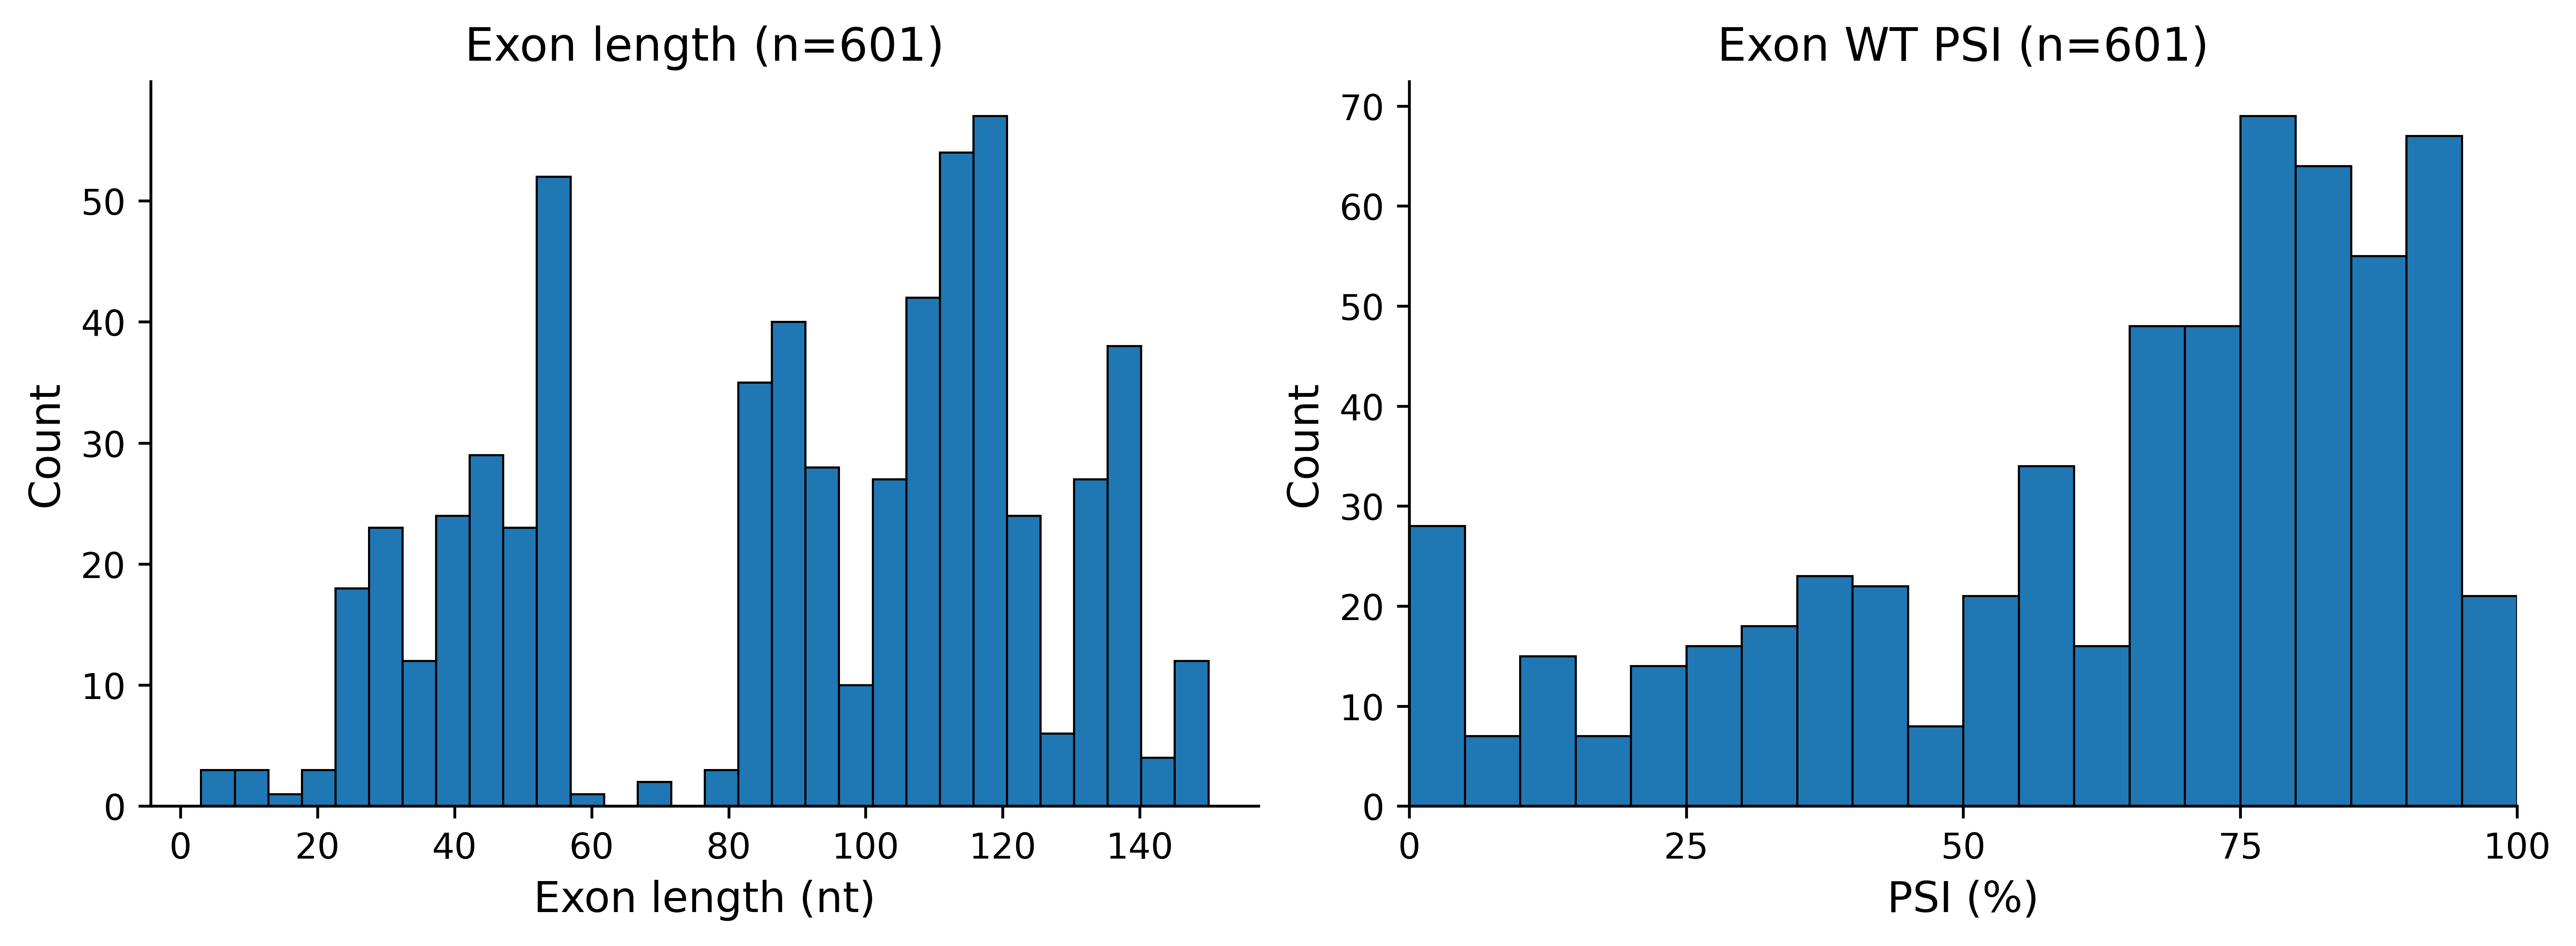

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True, dpi=600)

# Exon length histogram
ax[0].hist(wt_exons["exon_length"], bins=30, edgecolor="black", linewidth=0.6)
ax[0].set_xlabel("Exon length (nt)")
ax[0].set_ylabel("Count")
ax[0].set_title("Exon length (n=601)")

# PSI histogram
ax[1].hist(wt_exons["psi"], bins=20, range=(0, 100),
           edgecolor="black", linewidth=0.6)
ax[1].set_xlim(0, 100)
ax[1].set_xticks([0, 25, 50, 75, 100])
ax[1].set_xlabel("PSI (%)")
ax[1].set_ylabel("Count")
ax[1].set_title("Exon WT PSI (n=601)")

plt.show()

---
## 3. Folded structure of the WT exons

**Note that here, I am trying to fold with the _actual_ splice-site flanking sequences, NOT those in the PNAS paper. This is different from the previous code.**

In [ ]:
import RNA
import utils

def rnafold_via_module(
    seqs,
    RNAfold_bin="RNAfold",
    temperature=37.0,
    maxBPspan=0,
    commands_file="",
    num_threads=8,
):
    """Drop-in replacement for utils.RNAfold backed by the ViennaRNA Python module.

    Same contract as the original: a list of (dot-bracket structure, MFE) pairs in
    input order. The executable-only arguments are accepted and ignored.
    """
    model_details = RNA.md()
    model_details.temperature = temperature
    if maxBPspan:
        model_details.max_bp_span = maxBPspan

    folded = []
    for seq in seqs:
        fold_compound = RNA.fold_compound(seq.upper().replace("T", "U"), model_details)
        structure, mfe = fold_compound.mfe()
        folded.append((structure, float(mfe)))
    return folded


utils.RNAfold = rnafold_via_module

from predict import predict  # noqa: E402  (import after the patch is installed)

In [ ]:
wt_exons["structure"], wt_exons["mfe"] = zip(
    *[(structure, mfe) for structure, mfe in rnafold_via_module(wt_exons["flanked_exon"])]
)
wt_exons["input_length"] = wt_exons["flanked_exon"].str.len()
wt_exons["mfe_per_nt"] = wt_exons["mfe"] / wt_exons["input_length"]

print(f"{len(wt_exons)} WT exons folded, "
      f"{wt_exons['input_length'].nunique()} distinct input lengths")
print(f"inputs at the trained length of 90 nt: "
      f"{int((wt_exons['input_length'] == 90).sum())} of {len(wt_exons)}")

601 WT exons folded, 102 distinct input lengths
inputs at the trained length of 90 nt: 0 of 601


In [ ]:
def count_stem_loops(structure, min_loop_size=3, min_stem_size=2):
    """
    Count terminal hairpin loops in RNA dot-bracket notation.

    Parameters
    ----------
    structure : str
        Dot-bracket structure containing '.', '(' and ')'.
    min_loop_size : int, default=3
        Minimum number of unpaired nucleotides in the hairpin loop.
    min_stem_size : int, default=2
        Minimum number of consecutive base pairs in the adjoining stem.
        The base pair closing the hairpin is included.

    Returns
    -------
    int
        Number of qualifying stem loops.
    """
    if not isinstance(structure, str):
        return 0
    if min_loop_size < 0 or min_stem_size < 1:
        raise ValueError("min_loop_size must be >= 0 and min_stem_size must be >= 1")

    stack = []
    pair_map = {}

    for i, char in enumerate(structure):
        if char == "(":
            stack.append(i)
        elif char == ")":
            if not stack:
                raise ValueError(f"Unmatched ')' at position {i}")
            left = stack.pop()
            pair_map[left] = i
            pair_map[i] = left
        elif char != ".":
            raise ValueError(f"Unsupported character {char!r} at position {i}")

    if stack:
        raise ValueError(f"Unmatched '(' at position {stack[-1]}")

    count = 0

    for left, right in pair_map.items():
        if left > right:
            continue

        # Hairpin interior must contain only unpaired nucleotides.
        loop = structure[left + 1:right]
        if len(loop) < min_loop_size or any(char != "." for char in loop):
            continue

        # Count consecutive base pairs extending outward from the loop.
        stem_size = 1
        outer_left, outer_right = left - 1, right + 1

        while (
            outer_left >= 0
            and outer_right < len(structure)
            and pair_map.get(outer_left) == outer_right
        ):
            stem_size += 1
            outer_left -= 1
            outer_right += 1

        if stem_size >= min_stem_size:
            count += 1

    return count

In [ ]:
wt_exons["n_stem_loops"] = wt_exons["structure"].apply(
    count_stem_loops,
    min_loop_size=3,
    min_stem_size=3,
)

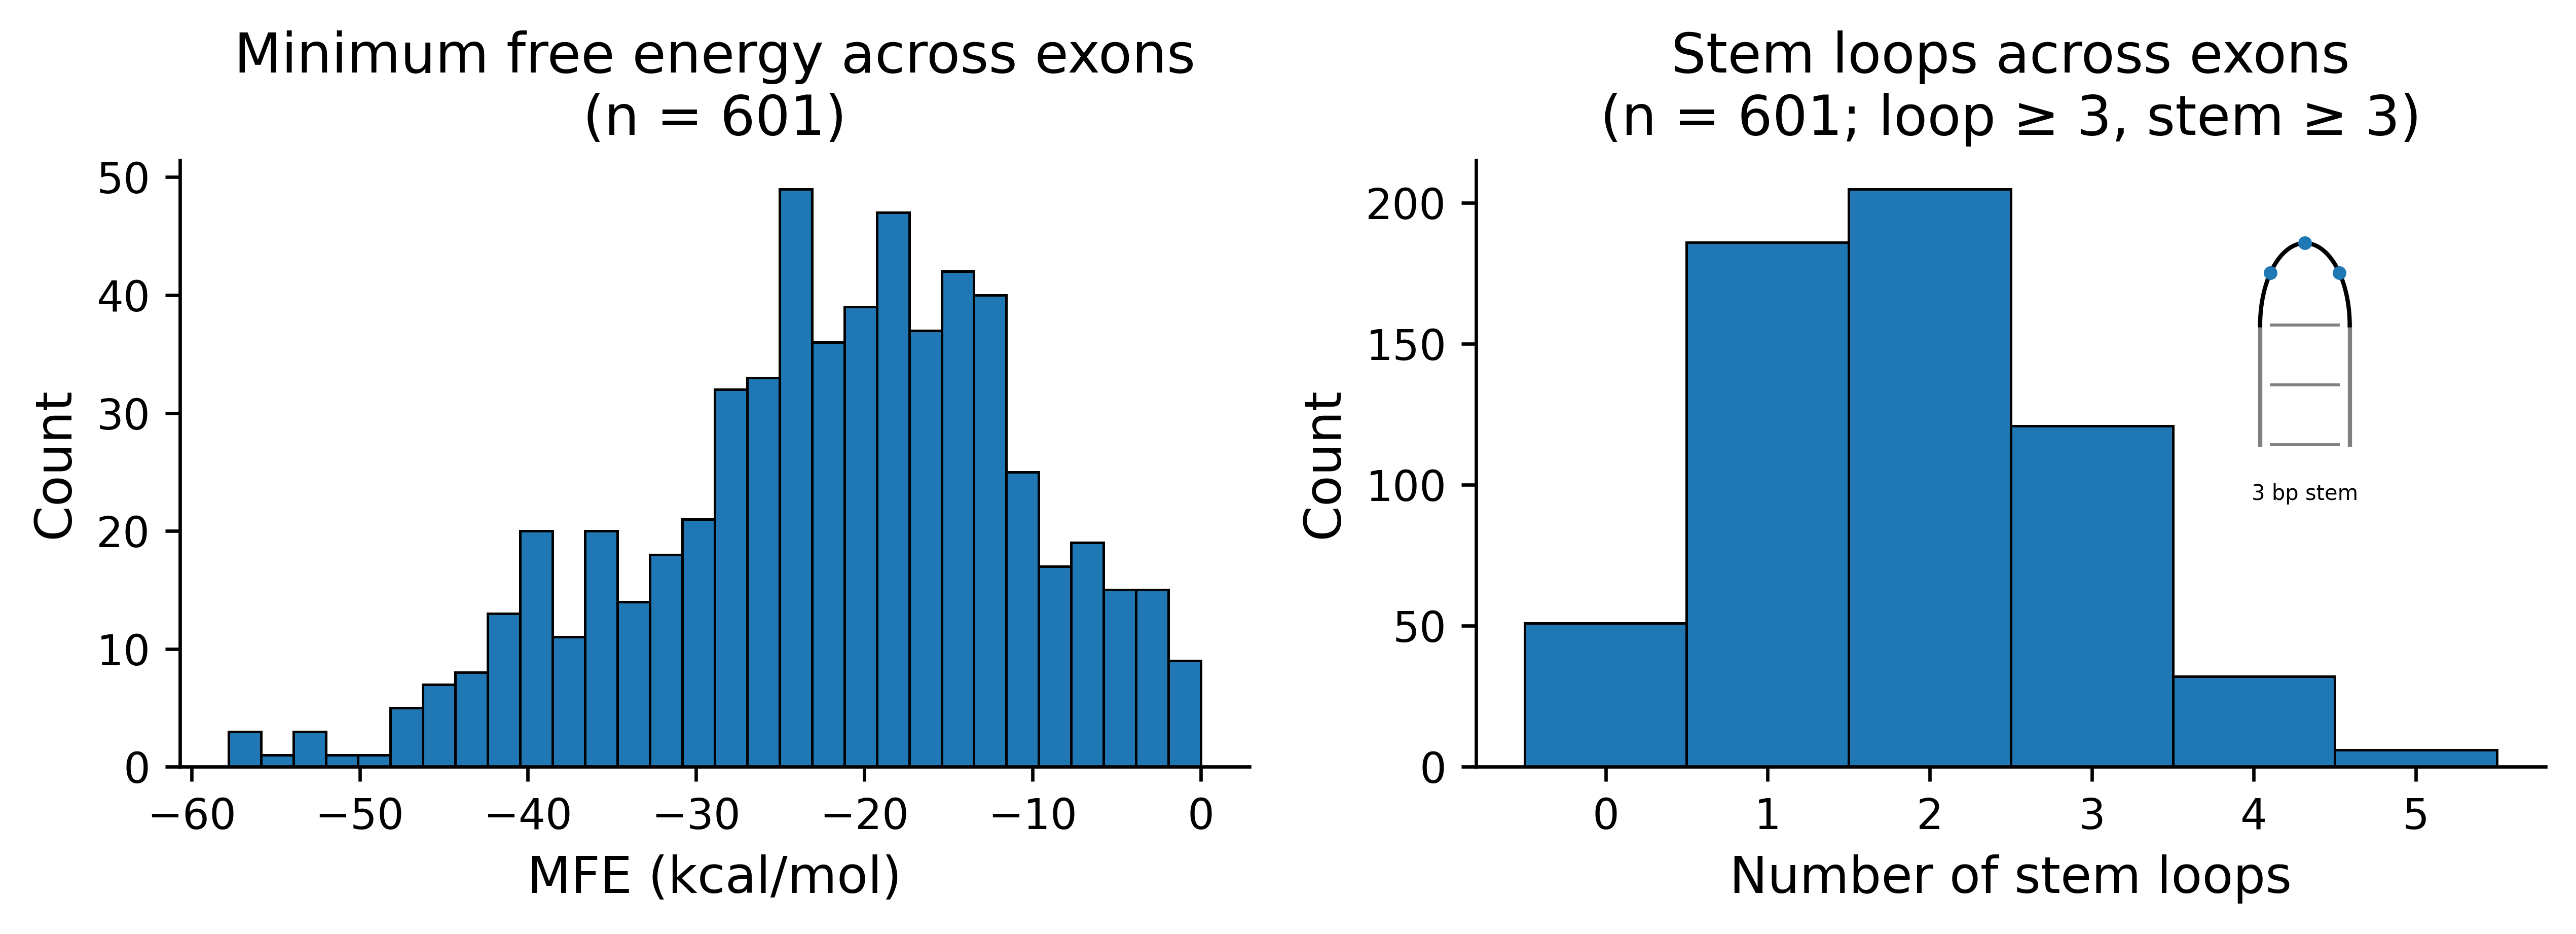

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mfe = wt_exons["mfe"].dropna()
stem_loops = wt_exons["n_stem_loops"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2), dpi=600)

# -------------------------
# MFE histogram
# -------------------------
axes[0].hist(mfe, bins=30, edgecolor="black", linewidth=0.6)
axes[0].set_xlabel("MFE (kcal/mol)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Minimum free energy across exons\n(n = {len(mfe):,})")

# -------------------------
# Stem-loop histogram
# -------------------------
bins = np.arange(
    int(stem_loops.min()) - 0.5,
    int(stem_loops.max()) + 1.5,
    1
)

axes[1].hist(
    stem_loops,
    bins=bins,
    edgecolor="black",
    linewidth=0.6
)

axes[1].set_xlabel("Number of stem loops")
axes[1].set_ylabel("Count")
axes[1].set_title(
    f"Stem loops across exons\n"
    f"(n = {len(stem_loops):,}; loop ≥ 3, stem ≥ 3)"
)
axes[1].set_xticks(
    range(int(stem_loops.min()), int(stem_loops.max()) + 1)
)

# -------------------------
# Tiny 3-bp stem / 3-nt loop schematic
# -------------------------
# Larger inset
inset = axes[1].inset_axes([0.60, 0.42, 0.35, 0.48])  # x, y, width, height

# Three-base-pair stem
left_x = np.array([0.38, 0.38, 0.38])
right_x = np.array([0.62, 0.62, 0.62])
stem_y = np.array([0.18, 0.34, 0.50])

inset.plot(left_x, stem_y, linewidth=1.0, color='gray')
inset.plot(right_x, stem_y, linewidth=1.0, color='gray')

# Base-pair connecting lines
for y in stem_y:
    inset.plot([0.41, 0.59], [y, y], linewidth=0.7, color='gray')

# Three-nucleotide terminal loop
theta = np.linspace(np.pi, 0, 100)
loop_x = 0.50 + 0.12 * np.cos(theta)
loop_y = 0.50 + 0.22 * np.sin(theta)

inset.plot(loop_x, loop_y, linewidth=1.0, color='black')

# Show three loop nucleotides
loop_angles = np.linspace(2.45, 0.69, 3)
dot_x = 0.50 + 0.12 * np.cos(loop_angles)
dot_y = 0.50 + 0.22 * np.sin(loop_angles)
inset.scatter(dot_x, dot_y, s=5, zorder=3)

inset.text(
    0.50, 0.02, "3 bp stem",
    ha="center", va="bottom", fontsize=5
)

inset.set_xlim(0.25, 0.75)
inset.set_ylim(0, 0.78)
inset.set_aspect("equal")
inset.axis("off")

# -------------------------
# Styling
# -------------------------
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(direction="out")

fig.tight_layout()
plt.show()

### Structure versus exon length

Total MFE grows with length, so the per-nucleotide value is the one to compare across
exons — shown side by side to make that explicit.

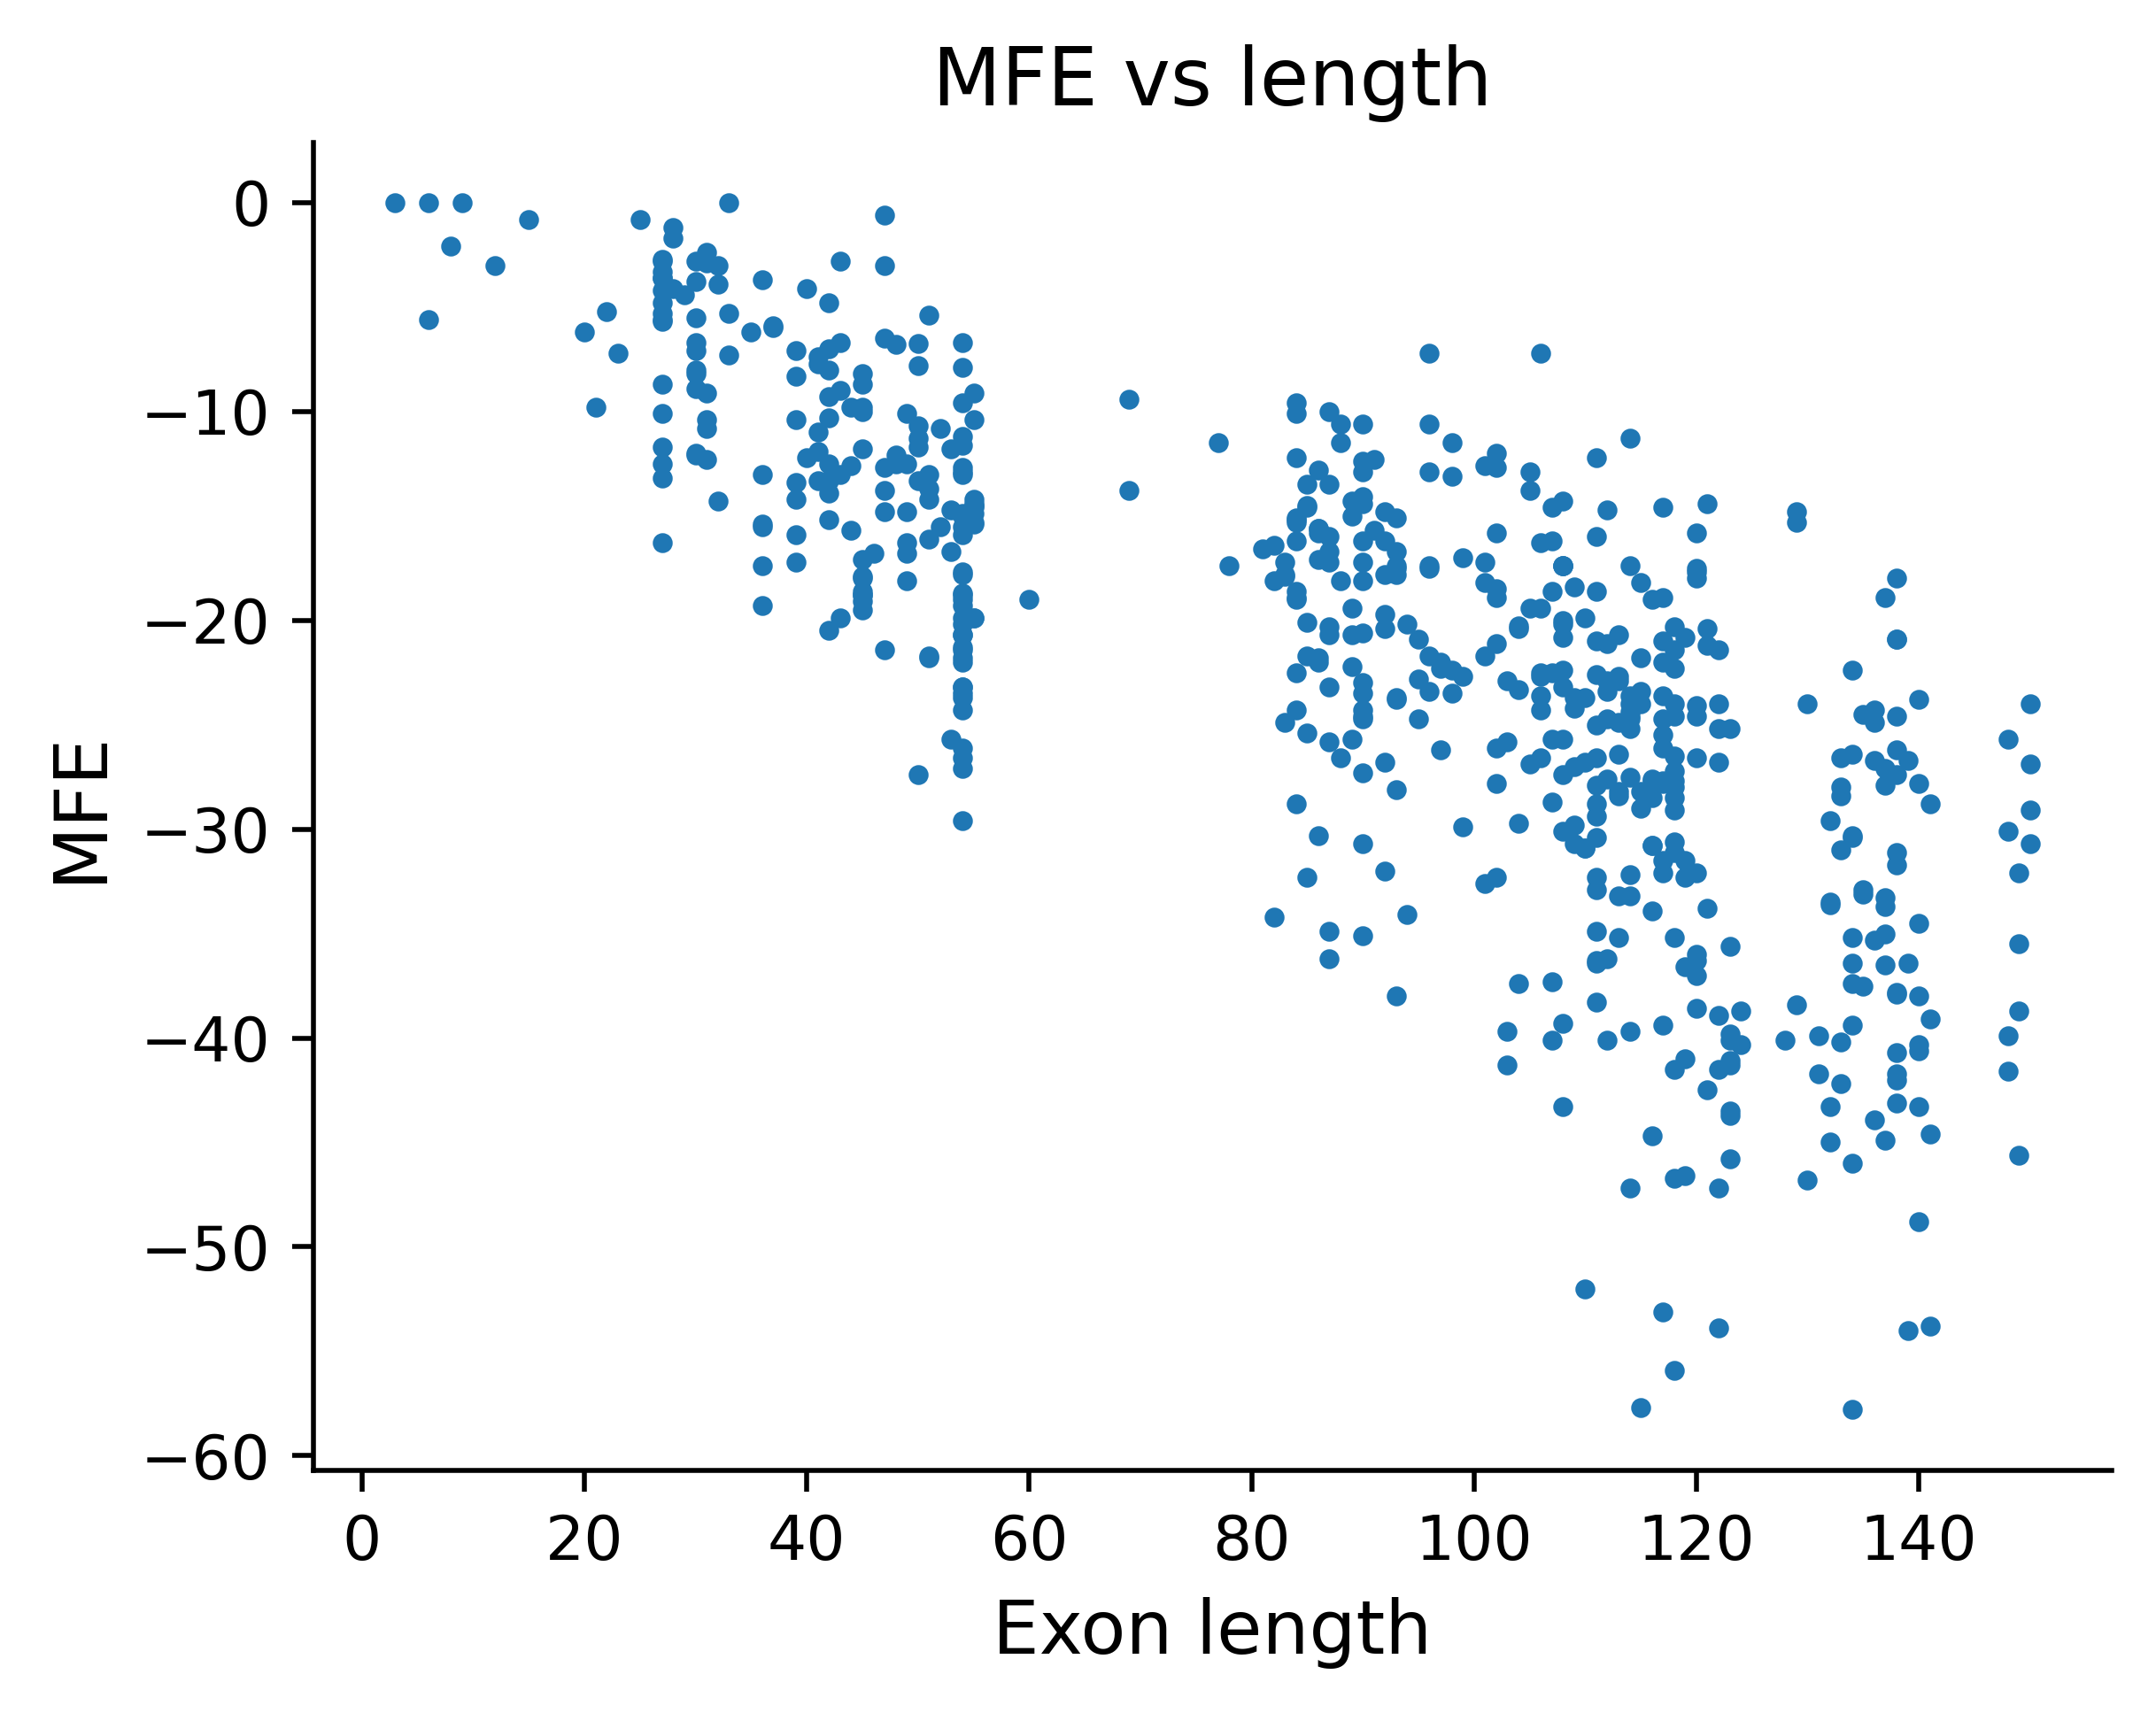

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=500)

ax.scatter(wt_exons["exon"].str.len(), wt_exons["mfe"], s=5)
ax.set_title("MFE vs length")
ax.set_ylabel("MFE")
ax.set_xlabel("Exon length")
despine(ax)

plt.tight_layout()
plt.show()

### Does measured WT PSI relate to length or structure?

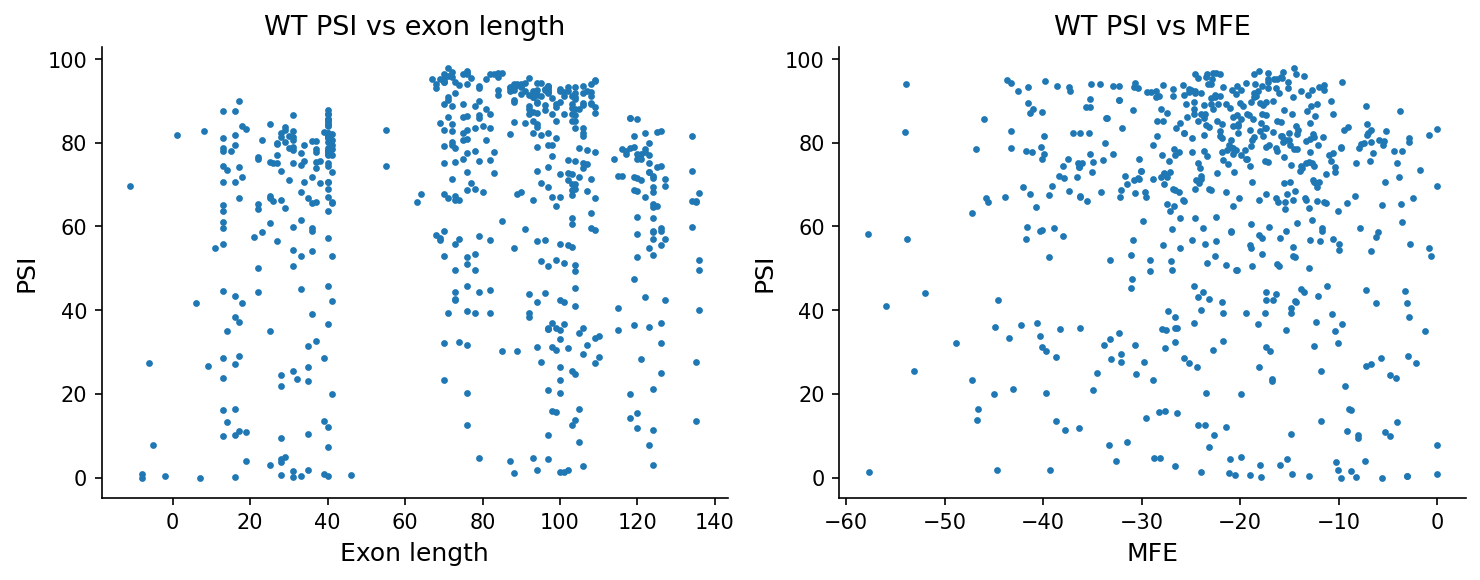

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

axes[0].scatter(wt_exons["exon"].str.len() - 14, wt_exons["psi"], s=5)
axes[0].set_title("WT PSI vs exon length")
axes[0].set_xlabel("Exon length")

axes[1].scatter(wt_exons["mfe"], wt_exons["psi"], s=5)
axes[1].set_title("WT PSI vs MFE")
axes[1].set_xlabel("MFE")

for ax in axes:
    ax.set_ylabel("PSI")
    despine(ax)

plt.tight_layout()
plt.show()

### The extremes

Most and least structured exons by MFE/nt, and the longest ones — these are the pool the
four case-study exons are picked from.

In [ ]:
extreme_cols = [
    "exon_id",
    "psi",
    "exon_length", "mfe",
    "flanked_exon"
]

pd.set_option('display.max_colwidth', None)
most_structured = wt_exons[extreme_cols].sort_values("mfe")
most_structured.head(10).round(3)

,exon_id,psi,exon_length,mfe,flanked_exon
321594,RHBG_e7,58.255,134,-57.8,CCTCCAGCCCATCCTTGAATCAAAATTCAAAGTCCAAGACACATGTGGAGTCCACAACCTCCATGGGATGCCGGGGGTCCTGGGGGCCCTCCTGGGGGTCCTTGTGGCTGGACTTGCCACCCATGAAGCTTACGGAGATGGGTGAGTT
367164,NPC1L1_e7,1.237,115,-57.7,CACACAGAGGCTGCCCCGGAGGCCTGGGGAGCCACGAGAGGTCCACATTGGGCGAGCCCTAGGCAGGGTGGCTCCCAGCATGCTGTTGTGCAGCCTCTCTGAGGCCATCTGCTTCTTCCTAGGTGAGCC
365490,GCNT1_e2,40.901,118,-55.9,CTGGCAGCGCTTTCTGCGCAGCACAGGCACCCTCGCCTGTCACGCCTCCCTCTCCTCTTCCCGTCTCCCAGCGTGGATGAGGGCGCCTGCAGATCCCGGCTAGGGCACGGACCGCCTAGGCCGAGGTAGGTT
719839,ESR2_e6,82.663,139,-54.0,TCCCCAGGCTTTGTGGAGCTCAGCCTGTTCGACCAAGTGCGGCTCTTGGAGAGCTGTTGGATGGAGGTGTTAATGATGGGGCTGATGTGGCGCTCAATTGACCACCCCGGCAAGCTCATCTTTGCTCCAGATCTTGTTCTGGACAGGTGAGAA
507354,MYH11_e17,94.064,122,-53.9,TTTGCAGTCCGGCAAGCTGGATGCGTTCCTGGTGCTGGAGCAGCTGCGGTGCAATGGGGTGCTGGAAGGCATTCGCATCTGCCGGCAGGGCTTCCCCAACCGGATCGTCTTCCAGGAGTTCCGCCAACGGTAAGTC
119825,FBLN2_e9,57.099,141,-53.8,CCACTAGACCAAGACGAGTGCCTGATGGGTGCTCACGATTGTAGCCGGCGACAGTTCTGTGTGAACACCCTGGGATCCTTCTACTGTGTCAACCACACAGTGCTCTGTGCCGATGGCTATATCCTCAATGCGCACAGGAAGTGCGTGGGTAAGCC
438643,PHYHD1_e11,25.449,117,-53.1,CCTGCAGGTGGTGTGTCAAGAAGGATGGTCCGGGCCCCTGTTGGCTCAGCGCCTGGTACCAGCTTCCTTGGGTCAGAGCCAGCCCGGGATAACAGCCTCTTTGTGCCCACCCCAGTGCAGAGAGGTAGGCA
793874,PDE2A_e5,43.990,110,-52.0,TTTTCAGGGAGGCTATCATCTCCCAGAAGCGGCTGGGCTGCAATGGGCTGGGCTTCTCAGACCTGCCAGGGAAGCCCTTGGCCAGGCTGGTGGCTCCACTGGCTCCTGATACCCAAGGTAAGGG
362253,COLQ_e13,32.071,140,-48.8,TTCCTAGGACAACTTATAATGGGACCCAAAGGGGAAAGAGGATTTCCCGGGCCTCCAGGAAGATGTCTTTGTGGACCCACTATGAATGTGAATAACCCTTCCTACGGGGAATCTGTGTATGGGCCCAGTTCCCCGCGAGTTCCTGTGGTAAGGC
197400,GDPD2_e2,23.208,114,-47.2,CCCCCAGGCCTTCACCATGGCCGAGTCCCCCGGCTGCTGCTCCGTCTGGGCCCGCTGCCTCCACTGCCTGTATAGCTGCCACTGGAGGAAATGCCCCAGAGAGAGGATGCAAACCAGCAAGGTGGAGT


In [ ]:
least_structured = wt_exons[extreme_cols].sort_values("mfe", ascending=False)
least_structured[least_structured.exon_length >= 50].head(5).round(3)

,exon_id,psi,exon_length,mfe,flanked_exon
276574,FBN1_e23,80.348,51,-5.40,ATTACAGATCCCATATGTGGTAAAGGGTACTCAAGAATTAAAGGAACACAATGTGAAGGTATTTC
426052,SCN1A_e25,80.244,54,-6.70,TTAATAGGCCACATTCAAAGGATGGATGGATATAATGTATGCAGCAGTTGATTCCAGAAATGTAAGTA
878414,BBS5_e4,54.071,50,-6.74,ATTTTAGCTGTCGGTTACAATTGCATATTGAATATTACAACAAGGACTGCTAACTCTGTAAGTC
559832,LCA5_e2,88.829,106,-7.20,TTTTAAGTATAAATGATCAACCAGAAATTATCTTCAAAGGAATAAAACCAGAAGTATGTAAATAAAAAGCCCAAGATAAAGAAACAGAAAAGCTGACACTACATGAAGCAGAGGTAATTC
564706,CCDC112_e8,44.923,96,-7.20,TTTTAAGGATTTACATAAACTTGAACTGAAAATTCTAGATAGACAGGCAAAGGAAGATGAAAAGTCACAAAAACAAAGAAGACTGGCAAAATTAAAAGAAAAGGTACTCT


In [ ]:
longest_exons = wt_df[extreme_cols].sort_values("exon_length", ascending=False)
longest_exons.head(10).round(3)

,exon_id,psi,exon_length,endogenous_ss_mfe,endogenous_ss_mfe_per_nt,exon_with_splice_site
240,COL12A1_e52,49.642,150.0,-26.9,-0.164,TTTTTAGGTTCATATTGTAGTGACCTCAAAAAGTGTTAAGATTTAC...
192,LRP1B_e32,51.977,150.0,-29.1,-0.177,ATTACAGGTCTATCGATAGACTATGTGGAAAACAAGCTTTATTGGA...
15,CCDC178_e21,40.123,150.0,-24.0,-0.146,CTTCTAGAAAATAATAGCTGATTCACTTGAAGAAAATCTGCGTTTA...
443,ATM_e57,67.954,150.0,-30.7,-0.187,ACTCCAGGTGGTTCCCCTCTCTCAGCGAAGTGGTGTTCTTGAATGG...
553,SNUPN_e2,13.467,149.0,-38.7,-0.237,TCTTTAGGGTCCACCTAAAGTGGGAAGTCTGTTTTCAAAATGACAT...
138,FIG4_e6,66.197,149.0,-35.5,-0.218,TTCTCAGTTACAGCTATGATTTGTCCCACTCACTTCAATATAATCT...
282,NBN_e3,27.738,149.0,-32.1,-0.197,TTTTCAGAGTCAAACAGATGAAATCCCTGTATTGACATTAAAAGAT...
320,PALB2_e12,65.960,149.0,-45.6,-0.280,AAATTAGGGGCTTCTCTTTATTGTCCTGAGTCATCCCTGTGCCAAA...
445,CNTNAP2_e4,81.611,148.0,-39.9,-0.246,TTTCCAGGCATTTCCCGGAAACATTAACTCTGACGGTGTGGTCCGG...
275,RET_e19,59.869,148.0,-41.6,-0.257,CTTCCAGGACTACTTGGACCTTGCGGCGTCCACTCCATCTGACTCC...


### How many variants do we have?

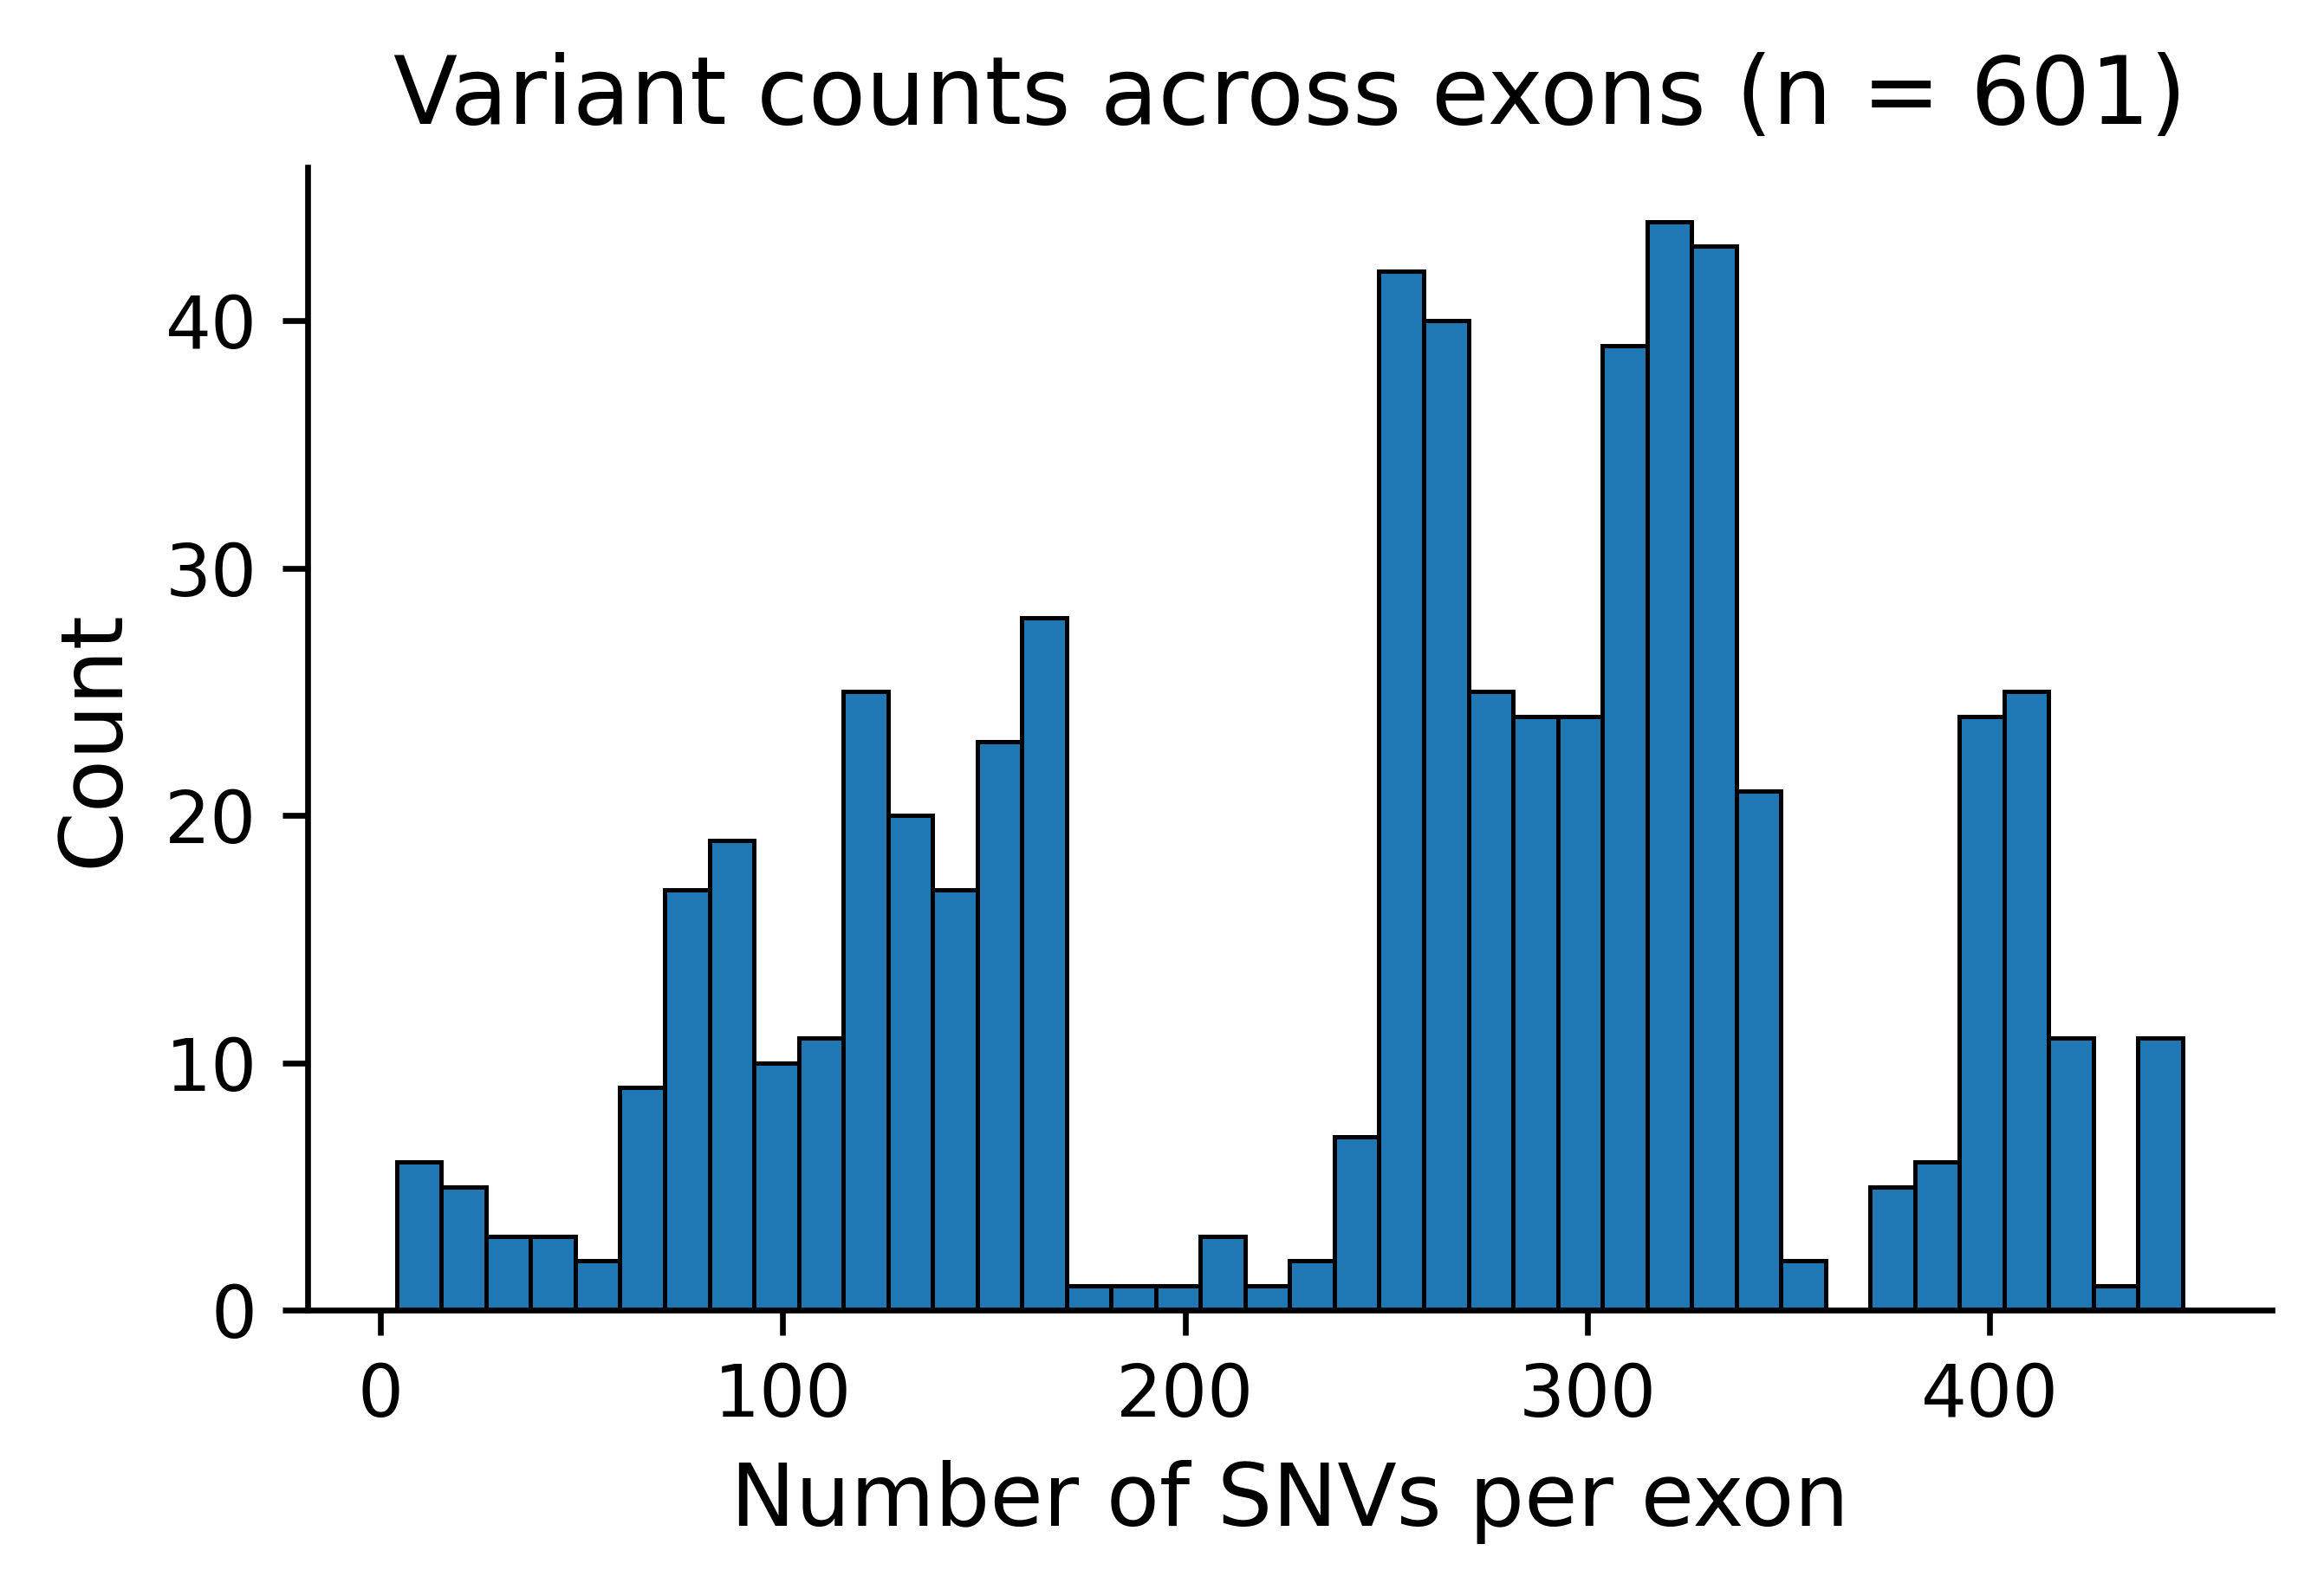

In [ ]:
variant_counts = (
    exonic_variants
    .dropna(subset=["psi"])
    ["exon_id"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(4.6, 3.2), dpi=600)

ax.hist(
    variant_counts,
    bins=40,
    edgecolor="black",
    linewidth=0.6
)

ax.set_xlabel("Number of SNVs per exon")
ax.set_ylabel("Count")
ax.set_title(f"Variant counts across exons (n = {len(variant_counts):,})")

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="out")

fig.tight_layout()
plt.show()